<a href="https://colab.research.google.com/github/Urooj25/Fashion_deeplearning_model/blob/main/Fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load training and testing data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# Class names for reference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)), # Converts 2D to 1D
    tf.keras.layers.Dense(128, activation='relu'), # Hidden layer
    tf.keras.layers.Dropout(0.2),                   # Overfitting prevention
    tf.keras.layers.Dense(10, activation='softmax') # Output layer
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training the model
print("--- Training Start ---")
model.fit(train_images, train_labels, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Training Start ---
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8112 - loss: 0.5283
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8533 - loss: 0.4030
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8649 - loss: 0.3674
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8712 - loss: 0.3511
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8773 - loss: 0.3319
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8796 - loss: 0.3216
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8854 - loss: 0.3085
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8874 - loss: 0.3015
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8928 - loss: 0.2910
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8920 - loss: 0.2870


In [4]:
print("\n--- Testing on Unseen Data ---")
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nTest Accuracy: {test_acc}')


--- Testing on Unseen Data ---
313/313 - 1s - 2ms/step - accuracy: 0.8801 - loss: 0.3445

Test Accuracy: 0.8801000118255615


Saving WhatsApp Image 2026-05-01 at 10.37.13 AM.jpeg to WhatsApp Image 2026-05-01 at 10.37.13 AM.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Model Result: T-shirt/top
Confidence: 98.52%


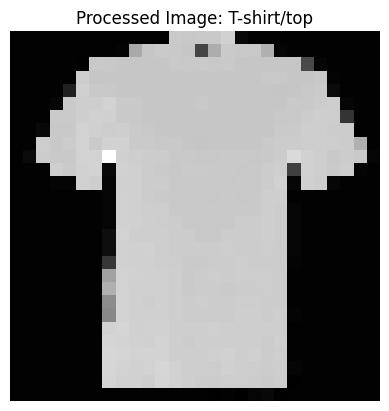

In [5]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# 1. Image upload
uploaded = files.upload()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

for file_name in uploaded.keys():
    try:

        img = Image.open(file_name).convert('L')

        #  Background Check

        img = ImageOps.invert(img)

        #  Standard Resize
        img = img.resize((28, 28), Image.NEAREST)

        # Normalization (0 to 1)
        img_array = np.array(img).astype('float32') / 255.0
        img_array = img_array.reshape(1, 28, 28)

        # 2. Pure Model Prediction
        prediction = model.predict(img_array)
        predicted_label = np.argmax(prediction)

        # 3. Display Result
        print(f"\nModel Result: {class_names[predicted_label]}")
        print(f"Confidence: {np.max(prediction)*100:.2f}%")

        plt.imshow(img, cmap='gray')
        plt.title(f"Processed Image: {class_names[predicted_label]}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error processing {file_name}: {e}")